## Classical ML Model #2: **Random Forest Classifier**

First, we will import our pre-split and scaled training, validation, and test sets.

In [1]:
import pandas as pd
import joblib

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

# **[4]** Model Selection Training


For the second model, we are implementing a **Random Forest Classifier**. This is a powerful ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. It is naturally robust to non-linear relationships and will help us easily interpret which socioeconomic features are most important for predicting urbanization.

### How Random Forest Works

A Random Forest operates by training a large number of individual Decision Trees, each on a randomly sampled subset of the training data (a process called **bootstrap aggregation**, or **bagging**). Each tree also only considers a random subset of features at every split, which decorrelates the trees from one another. When making a prediction, all trees cast a "vote" and the majority class wins. This approach reduces the variance of any single tree's decision, producing a model that is more stable and generalizable than a lone decision tree.

### Key Hyperparameters

Understanding the key hyperparameters is essential to interpreting both why the baseline model overfits and why tuning corrects it. The table below summarizes the hyperparameters relevant to this notebook:

| Hyperparameter | Default | Role |
|---|---|---|
| `n_estimators` | `100` | Number of decision trees in the forest. More trees generally improve stability, but with diminishing returns beyond a certain point. |
| `max_depth` | `None` | Maximum depth each tree is allowed to grow. Defaults to `None`, meaning trees grow until every leaf is pure — a major driver of overfitting on the baseline model. |
| `min_samples_split` | `2` | Minimum number of samples required to split an internal node. Higher values prevent the model from making splits based on very few data points. |
| `min_samples_leaf` | `1` | Minimum number of samples required at each leaf node. A value of `1` (default) allows the model to create leaves for individual data points, enabling memorization. |
| `max_features` | `'sqrt'` | Number of features considered at each split. Defaults to the square root of total features, which ensures diversity across trees. |
| `random_state` | `None` | Seed for the random number generator. We set this to `42` to guarantee reproducibility across runs. |
| `n_jobs` | `None` | Number of CPU cores used for parallel training. We set this to `-1` to use all available cores, maximizing training speed. |

### Baseline Model Initialization

For our baseline (pre-tuned) model, we use all default values except for `random_state` and `n_jobs`. This gives us an unconstrained Random Forest, one where trees are allowed to grow indefinitely deep.



In [2]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier Model
pre_tuned_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Train the model on the scaled training data
pre_tuned_rf.fit(X_train_scaled, y_train)

print("Random Forest model successfully trained!")

Random Forest model successfully trained!


Now, we will fit our baseline Random Forest model strictly on the training data. This will establish our baseline performance.

To evaluate the model's performance, we have established an evaluation function to calculates our global metrics (**Balanced Accuracy, AUC-ROC, and AUC-PR**) and our per-class metrics (**Precision, Recall, and F1-Score** for both Rural and Urban households). Finally, it plots a **Confusion Matrix** to visualize the raw prediction counts.

In [3]:
from sklearn.metrics import (
    balanced_accuracy_score, 
    classification_report, 
    roc_auc_score, 
    average_precision_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def evaluate_model_performance(model, X_eval, y_eval, dataset_name="Validation"):
    print(f"MODEL EVALUATION: {dataset_name.upper()} SET ")
    
    # Get standard predictions (0 or 1) and probabilities
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1] # Probability of Class 1 (Urban)
    
    # Calculate Global Metrics
    bal_acc = balanced_accuracy_score(y_eval, y_pred)
    auc_roc = roc_auc_score(y_eval, y_proba)
    auc_pr = average_precision_score(y_eval, y_proba)
    
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"AUC-ROC:           {auc_roc:.4f}")
    print(f"AUC-PR:            {auc_pr:.4f}\n")
    
    # Calculate Per-Class Metrics
    print("Per-Class Metrics:")
    print(classification_report(y_eval, y_pred, target_names=['Rural (0)', 'Urban (1)']))
    
    # Display the Confusion Matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(y_eval, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rural', 'Urban'])
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.show()
    
    # Return metrics for overfitting comparison
    return bal_acc, auc_roc

MODEL EVALUATION: TRAINING SET 
Balanced Accuracy: 1.0000
AUC-ROC:           1.0000
AUC-PR:            1.0000

Per-Class Metrics:
              precision    recall  f1-score   support

   Rural (0)       1.00      1.00      1.00     17358
   Urban (1)       1.00      1.00      1.00     10761

    accuracy                           1.00     28119
   macro avg       1.00      1.00      1.00     28119
weighted avg       1.00      1.00      1.00     28119

Confusion Matrix:


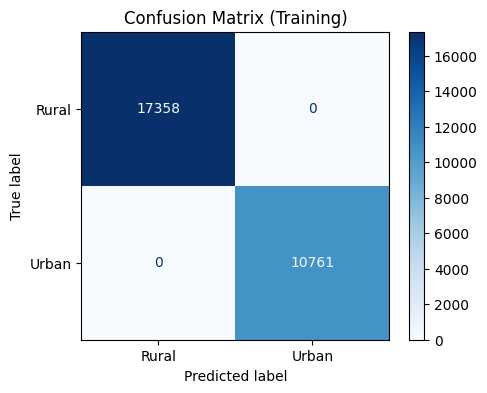

In [4]:
# Evaluate on the training data using the pre-tuned model
train_bal_acc, train_auc_roc = evaluate_model_performance(pre_tuned_rf, X_train_scaled, y_train, "Training")

The pre-tuned baseline model achieves **perfect scores across every metric** on the training data, Balanced Accuracy, AUC-ROC, and AUC-PR all read 1.0000, and every per-class Precision, Recall, and F1-Score is exactly 1.00 for both Rural and Urban households.

While this may appear impressive, they are a **red flag for overfitting**. What these results tell us is that the unconstrained Random Forest has memorized the training data entirely. With `max_depth=None` and `min_samples_leaf=1`, the decision trees were allowed to grow until every single training sample had its own leaf node, effectively encoding every data point as a rule. The confusion matrix will confirm zero misclassifications on the training set.

This behavior is mathematically expected for a default Random Forest on a dataset of this size. The training evaluation serves purely as a **baseline reference point** to confirm that the model trained successfully and to highlight the gap that will emerge when we evaluate on unseen data.

To determine if our model simply memorized the training data or actually learned generalizable socioeconomic patterns, we will now evaluate it on the **Validation Set**. We will use the exact same evaluation function.

MODEL EVALUATION: VALIDATION SET 
Balanced Accuracy: 0.7779
AUC-ROC:           0.8762
AUC-PR:            0.8429

Per-Class Metrics:
              precision    recall  f1-score   support

   Rural (0)       0.81      0.89      0.85      3720
   Urban (1)       0.79      0.66      0.72      2306

    accuracy                           0.81      6026
   macro avg       0.80      0.78      0.79      6026
weighted avg       0.80      0.81      0.80      6026

Confusion Matrix:


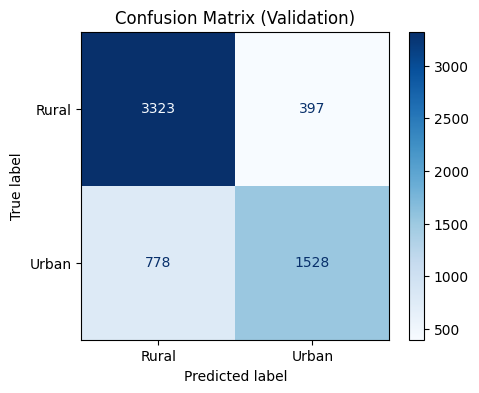

In [5]:
# Evaluate on the validation data using the pre-tuned model
val_bal_acc, val_auc_roc = evaluate_model_performance(pre_tuned_rf, X_val_scaled, y_val, "Validation")

When evaluated on the unseen validation set, the model's performance drops substantially, confirming that the perfect training scores were the result of memorization rather than genuine learning.

- **Balanced Accuracy: 0.7779** — The model correctly classifies roughly 77.8% of households on average across both classes. This is a meaningful drop from the perfect training score, but it is not catastrophic since the model has still learned real patterns, just not as cleanly as the training results showed.
- **AUC-ROC: 0.8762** — The model's ability to rank Urban households above Rural ones is reasonably strong. A score of 0.8762 means that given a random Urban and a random Rural household, the model assigns a higher probability of being Urban to the correct one ~87.6% of the time. This indicates that the underlying probability estimates are still fairly well-calibrated.
- **AUC-PR: 0.8429** — The precision-recall trade-off is also reasonable, though the drop from 1.0 is notable and reflects some degradation in the model's confidence on the minority (Urban) class.
- **Rural (0) — Precision: 0.81, Recall: 0.89, F1: 0.85:** The model performs reasonably well on Rural households. It correctly identifies 89% of actual Rural households (high Recall), though 19% of its Rural predictions turn out to be wrong (precision of 0.81).
- **Urban (1) — Precision: 0.79, Recall: 0.66, F1: 0.72:** Urban classification is noticeably weaker. The model only catches 66% of actual Urban households (low Recall). This asymmetry is the most important weakness of the pre-tuned model, it is biased toward predicting Rural, likely because Rural is the majority class (61.7% of the dataset).

The validation results confirm overfitting and expose a class-skewed bias. The model is better at identifying Rural households than Urban ones, and its per-class performance is considerably weaker than the training results suggested. This justifies the hyperparameter tuning we will perform next.

Afterward, we will calculate the drop-off in our metrics between the training and validation sets. A significant drop indicates that the complex Random Forest trees have overfitted to the training noise.

We create another function compute all the relevant metrics for a given set of true labels, predicted labels, and predicted probabilities.

In [6]:
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)

def get_all_metrics(y_true, y_pred, y_proba):
    return {
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_proba),
        "AUC-PR": average_precision_score(y_true, y_proba),
        "Rural Precision": precision_score(y_true, y_pred, pos_label=0),
        "Urban Precision": precision_score(y_true, y_pred, pos_label=1),
        "Rural Recall": recall_score(y_true, y_pred, pos_label=0),
        "Urban Recall": recall_score(y_true, y_pred, pos_label=1),
        "Rural F1-Score": f1_score(y_true, y_pred, pos_label=0),
        "Urban F1-Score": f1_score(y_true, y_pred, pos_label=1)
    }

Now let us compute for the drop-off in our metrics between the training and validation sets.

In [7]:
# Generate predictions for both Train and Validation sets
y_train_pred = pre_tuned_rf.predict(X_train_scaled)
y_train_proba = pre_tuned_rf.predict_proba(X_train_scaled)[:, 1]

y_val_pred = pre_tuned_rf.predict(X_val_scaled)
y_val_proba = pre_tuned_rf.predict_proba(X_val_scaled)[:, 1]

# Calculate metrics for both sets
train_metrics = get_all_metrics(y_train, y_train_pred, y_train_proba)
val_metrics = get_all_metrics(y_val, y_val_pred, y_val_proba)

print("OVERFITTING ANALYSIS: METRIC DROP-OFF (TRAIN vs VAL) ")

for metric in train_metrics.keys():
    drop = train_metrics[metric] - val_metrics[metric]
    print(f"Drop in {metric.ljust(18)}: {drop:.4f}")

OVERFITTING ANALYSIS: METRIC DROP-OFF (TRAIN vs VAL) 
Drop in Balanced Accuracy : 0.2221
Drop in AUC-ROC           : 0.1238
Drop in AUC-PR            : 0.1571
Drop in Rural Precision   : 0.1897
Drop in Urban Precision   : 0.2062
Drop in Rural Recall      : 0.1067
Drop in Urban Recall      : 0.3374
Drop in Rural F1-Score    : 0.1502
Drop in Urban F1-Score    : 0.2777


Based on the metric drop-off analysis between the Training and Validation sets, it is clear that our baseline Random Forest model is suffering from **overfitting**.

While the model achieved perfect scores (1.0000) during the training phase, it experienced severe performance degradation when exposed to the unseen Validation Set:
* **Balanced Accuracy** dropped by **22.21%**, the largest global drop, confirming that the model's ability to correctly classify both Rural and Urban households fairly collapsed on unseen data.
* **Urban Recall** suffered the steepest per-class drop at **33.74%**, meaning the model missed a significant portion of actual Urban households — classifying them as Rural. This is the most critical failure, as the model is far worse at catching Urban cases than the training results suggested.
* **Urban Precision** dropped by **20.62%** and **Rural Precision** by **18.97%**, indicating that predictions for both classes became substantially less reliable on the validation set.
* **Urban F1-Score** dropped by **27.77%** and **Rural F1-Score** by **15.02%**, reflecting the compounding effect of degraded precision and recall across both classes.
* Notably, the threshold-independent metrics (**AUC-ROC** dropped by **12.38%** and **AUC-PR** by **15.71%**) also saw significant drops, indicating that even the model's underlying probability rankings, not just its binary decisions, were compromised.

This is expected behavior for an unconstrained `RandomForestClassifier`. Because we did not specify a maximum depth (`max_depth`), which defaults to `None`, or a minimum number of samples per leaf (`min_samples_leaf`), which defaults to `1`, the decision trees grew infinitely deep until they mathematically memorized the exact noise and outliers of the training data.

To correct this, we will tune our hyperparameters. We will use cross-validation to find the optimal constraints that force the model to learn generalizable socioeconomic patterns rather than memorizing individual household data points.

# **[5]** Error Analysis and Model Tuning

Having identified overfitting in our pre-tuned model, we will now perform hyperparameter tuning to constrain the Random Forest's complexity. 

We will use Scikit-Learn's `GridSearchCV` to systematically test different combinations of tree depths, sample splits, and estimator counts. To ensure our pipeline strictly guards against data leakage, this search will be conducted **exclusively on the Training Set (`X_train_scaled` and `y_train`)**, utilizing 5-fold cross-validation. 

The search will prioritize **Balanced Accuracy** as its scoring metric.

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the grid of parameters to test
param_grid = {
    'n_estimators': [100, 300, 500],      # Number of trees in the forest
    'max_depth': [10, 15, 20],            # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],      # Minimum households required to split an internal node
    'min_samples_leaf': [1, 2, 4]         # Minimum households required to be at a leaf node
}

# Initialize Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=5,          # 5-fold cross-validation
    n_jobs=-1,
    verbose=1
)

# Fitting strictly on the training set
grid_search.fit(X_train_scaled, y_train)

# Extract the newly tuned model
post_tuned_rf = grid_search.best_estimator_

print("\nPre-Tuned Model Parameters (Defaults)")
print(f"n_estimators:      100")
print(f"max_depth:         None")
print(f"min_samples_split: 2")
print(f"min_samples_leaf:  1")

print("\nPost-Tuned Model Parameters (Best Found)")
print(f"n_estimators:      {post_tuned_rf.n_estimators}")
print(f"max_depth:         {post_tuned_rf.max_depth}")
print(f"min_samples_split: {post_tuned_rf.min_samples_split}")
print(f"min_samples_leaf:  {post_tuned_rf.min_samples_leaf}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Pre-Tuned Model Parameters (Defaults)
n_estimators:      100
max_depth:         None
min_samples_split: 2
min_samples_leaf:  1

Post-Tuned Model Parameters (Best Found)
n_estimators:      300
max_depth:         20
min_samples_split: 5
min_samples_leaf:  2


After executing a 5-fold cross-validated Grid Search on the training data, we have successfully identified the optimal hyperparameters to constrain our Random Forest model.

The search yielded the following optimal configuration:
* **`max_depth: 20`** (Changed from `None`): This is the most critical fix. By enforcing a hard ceiling of 20 levels, we stop the decision trees from growing infinitely deep. This prevents the model from creating microscopic, highly specific rules that merely memorize the training noise.
* **`n_estimators: 300`** (Changed from `100`): The search determined that tripling the number of trees in the forest improves the "wisdom of the crowd" effect. Averaging the predictions across 300 independent trees helps smooth out individual tree variances, further reducing overfitting and increasing the stability of our predictions.
* **`min_samples_split: 5`** (Changed from `2`): By requiring at least 5 households before a node can be split further, we prevent the model from creating overly specific branches based on just one or two data points, reducing noise memorization.
* **`min_samples_leaf: 2`** (Changed from `1`): Requiring at least 2 households at every leaf node ensures that no prediction is based on a single training sample, adding an additional layer of generalization.

Before we formally compare the pre-tuned and post-tuned models, let's visualize why the Grid Search selected `n_estimators = 300`. 

In a Random Forest, adding more trees generally improves performance by averaging out the errors of individual decision trees. However, this improvement eventually plateaus.

However, unlike Neural Networks, a Random Forest does not use gradient descent or calculate a "loss function" (like Binary Cross-Entropy) over multiple training epochs. Instead, it builds independent decision trees simultaneously. By plotting the **Validation Balanced Accuracy** against a growing number of trees (while keeping our optimal `max_depth=20`), we can visually confirm this concept of diminishing returns.

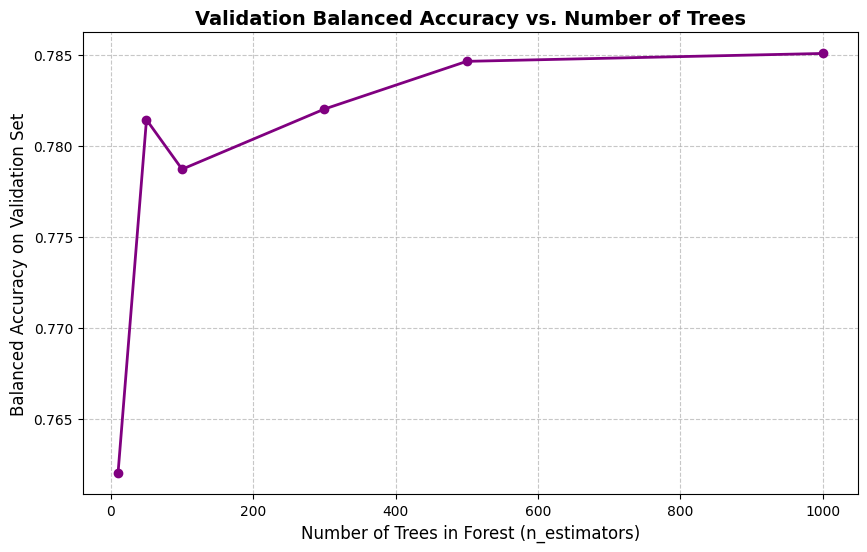

In [9]:
n_estimators_range = [10, 50, 100, 300, 500, 1000]
val_bal_acc_scores = []

# Loop through the range of n_estimators
for n in n_estimators_range:

    # We apply optimal max_depth=20 to isolate the effect of adding trees
    temp_rf = RandomForestClassifier(
        n_estimators=n, 
        max_depth=20, 
        random_state=42, 
        n_jobs=-1
    )
    temp_rf.fit(X_train_scaled, y_train)
    temp_preds = temp_rf.predict(X_val_scaled)
    
    # Use Balanced Accuracy
    score = balanced_accuracy_score(y_val, temp_preds)
    val_bal_acc_scores.append(score)


plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, val_bal_acc_scores, marker='o', linestyle='-', color='purple', linewidth=2)
plt.title('Validation Balanced Accuracy vs. Number of Trees', fontsize=14, fontweight='bold')
plt.xlabel('Number of Trees in Forest (n_estimators)', fontsize=12)
plt.ylabel('Balanced Accuracy on Validation Set', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

The plot above illustrates how the model's Validation Balanced Accuracy changes as the number of trees (`n_estimators`) increases, with all other hyperparameters held constant at their optimal values (`max_depth=20`, `random_state=42`).

While increasing the number of trees in a random forest generally improves performance up to a point, it is not "always better". The algorithm will eventually hit a plateau, and the additional trees only increase computational costs without any significance increase in the model's performance. 

The Grid Search correctly selected **`n_estimators = 300`** as the optimal value, it sits at the beginning of the plateau, capturing the full performance benefit while avoiding the unnecessary computational overhead of 500 or 1,000 trees.

To further evaluate our current hyperparameters, let us now compare the performance of our pre-tuned and post-tuned model.

In [10]:
# Generate predictions for the Validation set using the POST-TUNED model
y_val_pred_tuned = post_tuned_rf.predict(X_val_scaled)
y_val_proba_tuned = post_tuned_rf.predict_proba(X_val_scaled)[:, 1]

# Calculate metrics for the post-tuned model 
val_metrics_tuned = get_all_metrics(y_val, y_val_pred_tuned, y_val_proba_tuned)

print("PERFORMANCE COMPARISON: PRE-TUNED vs POST-TUNED")

for metric in val_metrics.keys():
    change = val_metrics_tuned[metric] - val_metrics[metric]
    sign = "+" if change > 0 else ""
    print(f"Change in {metric.ljust(18)}: {sign}{change:.4f}")

PERFORMANCE COMPARISON: PRE-TUNED vs POST-TUNED
Change in Balanced Accuracy : +0.0062
Change in AUC-ROC           : +0.0015
Change in AUC-PR            : +0.0033
Change in Rural Precision   : +0.0050
Change in Urban Precision   : +0.0061
Change in Rural Recall      : +0.0024
Change in Urban Recall      : +0.0100
Change in Rural F1-Score    : +0.0038
Change in Urban F1-Score    : +0.0085


After applying the optimal hyperparameters found by GridSearchCV, every single metric improved on the validation set, confirming that the tuning was effective. While the improvements are really small, they are consistent and meaningful for several reasons:

- **All changes are positive.** There is not a single metric that degraded after tuning. This is strong evidence that the chosen hyperparameters genuinely improved generalization rather than simply trading one metric for another.
- **Urban Recall improved the most (+0.0100).** Recall for Urban households was the weakest metric in the pre-tuned model (0.66), so any improvement here is especially valuable. The tuned model catches more actual Urban households that the baseline was misclassifying as Rural.
- **Urban F1-Score improved by +0.0085**, reflecting the compounded gains in both Urban Precision and Recall. Since Urban is the minority class, improvements here are harder to achieve and more impactful for overall fairness.

The post-tuned model is now our final candidate for test set evaluation.

# **[6]** Model Evaluation

With our model fully tuned, we will now perform our final evaluation using the isolated test set. This provides an unbiased look at how our optimized Random Forest will perform on completely unseen household data.

MODEL EVALUATION: TEST SET 
Balanced Accuracy: 0.7899
AUC-ROC:           0.8849
AUC-PR:            0.8562

Per-Class Metrics:
              precision    recall  f1-score   support

   Rural (0)       0.82      0.91      0.86      3720
   Urban (1)       0.82      0.67      0.74      2306

    accuracy                           0.82      6026
   macro avg       0.82      0.79      0.80      6026
weighted avg       0.82      0.82      0.81      6026

Confusion Matrix:


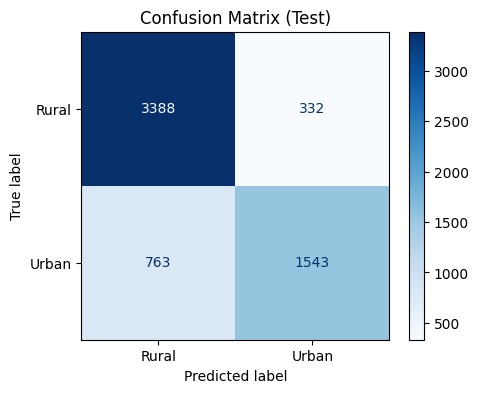


Final Test Set Metrics
Balanced Accuracy : 0.7899
AUC-ROC           : 0.8849
AUC-PR            : 0.8562
Rural Precision   : 0.8162
Urban Precision   : 0.8229
Rural Recall      : 0.9108
Urban Recall      : 0.6691
Rural F1-Score    : 0.8609
Urban F1-Score    : 0.7381


In [11]:
# Use the best model from Grid Search to predict the test set
y_test_pred = post_tuned_rf.predict(X_test_scaled)
y_test_proba = post_tuned_rf.predict_proba(X_test_scaled)[:, 1]

# Calculate final metrics
test_bal_acc, test_auc_roc = evaluate_model_performance(post_tuned_rf, X_test_scaled, y_test, "Test")

test_metrics = get_all_metrics(y_test, y_test_pred, y_test_proba)

print("\nFinal Test Set Metrics")
for metric, value in test_metrics.items():
    print(f"{metric.ljust(18)}: {value:.4f}")

## Feature Importance Analysis
One of the primary advantages of the Random Forest algorithm is its interpretability. Below, we extract the feature importances from our best model to understand which household characteristics were the strongest predictors of urbanization.

Random Forest calculates feature importance using **Mean Decrease in Impurity (MDI)**, a measure of how much each feature reduces uncertainty (Gini impurity) across all decision trees in the forest, averaged over all 300 trees. A higher score means the model relied more heavily on that feature when making splits. All importance scores are normalized to sum to 1.0, so each value represents a feature's **relative share** of total predictive power.

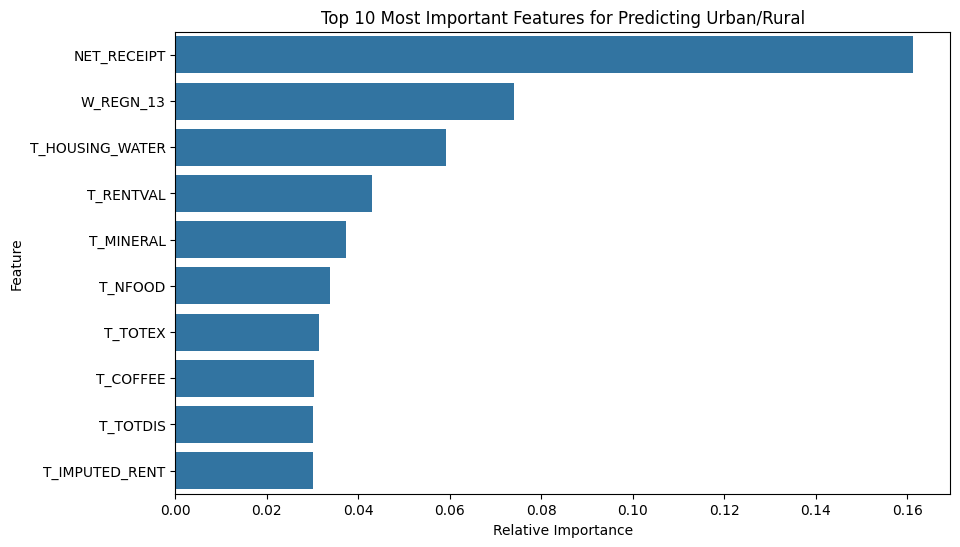

In [14]:
import seaborn as sns

# Extract feature importances from the tuned model
importances = post_tuned_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting the Top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Most Important Features for Predicting Urban/Rural')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

### Top 10 Features and Their Interpretation

**1. `NET_RECEIPT` (~0.16) — Total Net Receipts from Family Sustenance Activity**
This is the single most dominant predictor by a significant margin, with over twice the importance of the second-ranked feature. `NET_RECEIPT` captures income from family sustenance activities, such as farming, fishing, or backyard livestock raising, which are inherently rural in nature. Urban households typically have near-zero values for this feature, while rural households report substantial receipts. The model found this asymmetry to be the strongest signal for separating the two classes.

**2. `W_REGN_13` (~0.075) — NCR (National Capital Region) Indicator**
This is the one-hot encoded dummy variable for Region 13 (NCR / Metro Manila), the only purely urban region in the Philippines. Because `drop_first=True` was applied during encoding, this variable equals `1` if the household belongs to NCR and `0` otherwise. Its high ranking confirms a geographic truth: being located in NCR is one of the strongest individual indicators of urban classification. Its placement as the second most important feature reflects how geographically concentrated urbanization is in the Philippines.

**3. `T_HOUSING_WATER` (~0.06) — Total Housing, Water, Electricity, Gas & Other Fuels Expenditure**
Urban households consistently spend more on formal housing infrastructure, higher actual rents, utility bills, and water service fees. This feature aggregates these costs, creating a reliable urban-rural divide. Rural households either own their homes outright, rely on informal water sources, or have lower utility costs overall, leading to systematically lower values.

**4. `T_RENTVAL` (~0.043) — House Rental Value (Actual + Imputed)**
Closely related to `T_HOUSING_WATER`, this feature captures the total rental value of a household's dwelling, including both actual rent paid and the imputed value of owner-occupied homes. Urban properties, especially in dense areas like NCR and CALABARZON, carry significantly higher market rental values, making this a strong discriminator. Its importance is consistent with the well-documented urban-rural housing cost gap.

**5. `T_MINERAL` (~0.037) — Expenditure on Mineral Water, Soft Drinks & Juices**
While this may appear surprising at first glance, `T_MINERAL` is a reliable proxy for disposable income and access to commercial goods. Urban households have greater access to convenience stores, supermarkets, and fast food, and tend to spend more on packaged beverages. Rural households, by contrast, rely more on natural water sources and homemade drinks. The model effectively uses this as a secondary income/lifestyle signal.

**6. `T_NFOOD` (~0.034) — Total Non-Food Expenditure**
This aggregate captures all spending outside of food, clothing, housing, transport, communication, recreation, and education. Urban lifestyles carry substantially higher non-food costs due to commuting, formal education, communication services, and discretionary spending. Its high importance reflects that urbanization is not just about income but about an entire spending structure that differs from rural households.

**7. `T_TOTEX` (~0.031) — Total Expenditure**
As the sum of food and non-food expenditure, `T_TOTEX` is a broad measure of household consumption capacity. Urban households spend significantly more in absolute terms, capturing the higher cost of living. This feature is partially redundant with `T_NFOOD` and `T_HOUSING_WATER` (which are components of it), which is likely why it ranks slightly lower, the forest already extracts the key variance from the sub-components.

**8. `T_COFFEE` (~0.030) — Expenditure on Coffee, Cocoa & Tea**
Similar to `T_MINERAL`, coffee expenditure serves as a lifestyle and access proxy. Urban households have greater access to commercial coffee products, café culture, and packaged beverages. This feature, while modest in its individual importance, contributes to a broader pattern of commercially-oriented consumption that characterizes urban households.

**9. `T_TOTDIS` (~0.029) — Total Disbursements**
`T_TOTDIS` extends `T_TOTEX` by including other disbursements such as loan repayments, real property purchases, bank deposits, and investments. Urban households are more likely to participate in formal financial systems, paying mortgages, saving in banks, or repaying consumer loans. This feature thus captures financial formalization, which is strongly associated with urban living.

**10. `T_IMPUTED_RENT` (~0.029) — Imputed House Rental Value**
For owner-occupied dwellings, this is the estimated market rent the household would pay if they were renting. Urban properties command dramatically higher imputed rents due to land values and proximity to commercial centers. This feature reinforces the signal already present in `T_RENTVAL` and `T_HOUSING_WATER`, but the model found it independently useful enough to rank in the top 10.

### Key Takeaways

The feature importance profile tells a story: **urbanization in the FIES 2012 dataset is primarily captured by three overlapping signals:**

- **Income source composition** — `NET_RECEIPT` reveals whether a household earns from subsistence activities, the hallmark of rural life.
- **Geography** — `W_REGN_13` directly flags NCR membership, the country's urban core.
- **Cost-of-living and consumption patterns** — Housing costs (`T_HOUSING_WATER`, `T_RENTVAL`, `T_IMPUTED_RENT`), total expenditure (`T_TOTEX`, `T_NFOOD`, `T_TOTDIS`), and lifestyle spending (`T_MINERAL`, `T_COFFEE`) collectively reflect the higher-cost, commercially-integrated consumption structure of urban households.

It is worth noting a limitation of MDI-based importance: features that are **correlated with each other** (e.g., `T_TOTEX`, `T_NFOOD`, `T_TOTDIS`) tend to **split importance among themselves**, meaning their individual scores underrepresent their combined predictive value. The model may be leveraging these expenditure features as a cluster rather than relying on any one of them individually.

In [13]:
import os

os.makedirs('model_outputs', exist_ok=True)

# Save the final locked-in model
joblib.dump(post_tuned_rf, 'model_outputs/random_forest_final_model.pkl')

# Create a DataFrame of the Test Set predictions and probabilities
rf_test_results = pd.DataFrame({
    'Actual_y_test': y_test,
    'RF_Predicted_Class': y_test_pred,
    'RF_Predicted_Probability': post_tuned_rf.predict_proba(X_test_scaled)[:, 1]
})

# Export to CSV for easy comparison in the main directory
rf_test_results.to_csv('model_outputs/rf_test_predictions.csv', index=False)